In [44]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [45]:
front_2Dcoord = np.load('front_image.npy', allow_pickle=True)
back_2Dcoord = np.load('back_image.npy', allow_pickle=True)
front_img = cv2.imread('front.png')

(12, 2) (12, 2)


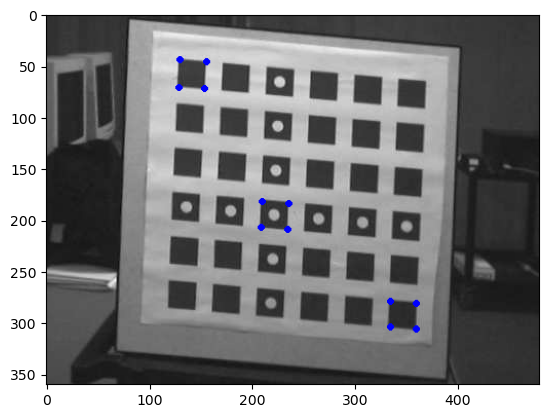

In [46]:
#visualization
print(front_2Dcoord.shape, back_2Dcoord.shape)
from copy import deepcopy
vis_img = deepcopy(front_img)
for i in range(front_2Dcoord.shape[0]):
    cv2.circle(vis_img, (int(front_2Dcoord[i, 0]), int(front_2Dcoord[i, 1])), 2, (255, 0, 0), 2)
plt.imshow(vis_img[:, :, ::-1])
plt.show()

In [47]:
# ------------TODO----------------
# Compute corresponding 3D coordinate
# ------------TODO----------------

front_3Dcoord = np.zeros((12, 3))
back_3Dcoord = np.zeros((12, 3))

# points are in the clockwise order from top-left to bottom-right
x_3Dcoord = [0, 50, 50, 0, 160, 210, 210, 160, 400, 450, 450, 400]
y_3Dcoord = [0, 0, 50, 50, 240, 240, 290, 290, 400, 400, 450, 450]
front_3Dcoord[:, 0] = x_3Dcoord
back_3Dcoord[:, 0] = x_3Dcoord
front_3Dcoord[:, 1] = y_3Dcoord
back_3Dcoord[:, 1] = y_3Dcoord
back_3Dcoord[:, 2] = 150

all_2Dcoord = np.concatenate((front_2Dcoord, back_2Dcoord), axis=0)
all_3Dcoord = np.concatenate((front_3Dcoord, back_3Dcoord), axis=0)
print(all_2Dcoord.shape, all_3Dcoord.shape)

(24, 2) (24, 3)


In [48]:
# ------------TODO----------------
# Construct the Equation Pm=0 and solve m
# ------------TODO----------------

P = np.zeros((48, 12))
m = np.zeros((12, 1))
P[::2, 0: 3] = all_3Dcoord
P[::2, 3] = 1
P[::2, 8: 11] = all_3Dcoord
P[::2, 11] = 1
P[::2, 8: 12] *= -all_2Dcoord[:, 0].reshape((-1, 1))

P[1::2, 4: 7] = all_3Dcoord
P[1::2, 7] = 1
P[1::2, 8: 11] = all_3Dcoord
P[1::2, 11] = 1
P[1::2, 8: 12] *= -all_2Dcoord[:, 1].reshape((-1, 1))
# for i in range(48):
#     if i % 2 == 0:
#         P[i, 0: 3] = all_3Dcoord[i // 2]
#         P[i, 3] = 1
#         P[i, 8: 11] = all_3Dcoord[i // 2]
#         P[i, 11] = 1
#         P[i, 8: 12] *= -all_2Dcoord[i // 2, 0]
#     else:
#         P[i, 4: 7] = all_3Dcoord[i // 2]
#         P[i, 7] = 1
#         P[i, 8: 11] = all_3Dcoord[i // 2]
#         P[i, 11] = 1
#         P[i, 8: 12] *= -all_2Dcoord[i // 2, 1]
U, D, V = np.linalg.svd(P, full_matrices=True)
m[:, 0] = V[-1]
scaled_M = m.reshape(3, 4)
scaled_A = scaled_M[:, 0: 3]
scaled_b = scaled_M[:, 3]

In [49]:
# ------------TODO----------------
# Solve K, and [R T] from m
# ------------TODO----------------
scale_factor = 1 / np.sqrt((scaled_A[2, :]**2).sum())
c_x = scale_factor**2 * np.dot(scaled_A[0, :], scaled_A[2, :])
c_y = scale_factor**2 * np.dot(scaled_A[1, :], scaled_A[2, :])
cos_theta = (np.dot(np.cross(scaled_A[1, :], scaled_A[2, :]), np.cross(scaled_A[2, :], scaled_A[0, :]))) \
    / (np.sqrt((np.cross(scaled_A[1, :], scaled_A[2, :])**2).sum()) * np.sqrt((np.cross(scaled_A[2, :], scaled_A[0, :])**2).sum()))
theta = np.arccos(cos_theta)
alpha = scale_factor**2 * np.sqrt((np.cross(scaled_A[0, :], scaled_A[2, :])**2).sum()) * np.sin(theta)
beta = scale_factor**2 * np.sqrt((np.cross(scaled_A[1, :], scaled_A[2, :])**2).sum()) * np.sin(theta)
r_1 = np.cross(scaled_A[1, :], scaled_A[2, :]) / np.sqrt((np.cross(scaled_A[1, :], scaled_A[2, :])**2).sum())
r_3 = scaled_A[2, :] / np.sqrt((scaled_A[2, :]**2).sum())
r_2 = np.cross(r_3, r_1)
K = np.zeros((3, 3))
R = np.zeros((3, 3))
T = np.zeros((3, 1))
K[0, 0] = alpha
K[0, 1] = -alpha / np.tan(theta)
K[0, 2] = c_x
K[1, 1] = beta / np.sin(theta)
K[1, 2] = c_y
K[2, 2] = 1
R[:, 0] = r_1.T
R[:, 1] = r_2.T
R[:, 2] = r_3.T
T = scale_factor * np.linalg.inv(K) @ scaled_b

In [50]:
# save results
save_dict = {'3Dcoord': all_3Dcoord, 'P':P, 'm':m, 'K':K, 'R':R, 'T':T}
np.save('../results/calibr', save_dict)

# The reference answer of T should be [383001.8386981  -67357.81794783  67071.11338303]
# The results are very strange because the data is fake.

In [ ]:
# np.load('../results/calibr.npy', allow_pickle=True)

array({'3Dcoord': array([[  0.,   0.,   0.],
       [ 50.,   0.,   0.],
       [ 50.,  50.,   0.],
       [  0.,  50.,   0.],
       [160., 240.,   0.],
       [210., 240.,   0.],
       [210., 290.,   0.],
       [160., 290.,   0.],
       [400., 400.,   0.],
       [450., 400.,   0.],
       [450., 450.,   0.],
       [400., 450.,   0.],
       [  0.,   0., 150.],
       [ 50.,   0., 150.],
       [ 50.,  50., 150.],
       [  0.,  50., 150.],
       [160., 240., 150.],
       [210., 240., 150.],
       [210., 290., 150.],
       [160., 290., 150.],
       [400., 400., 150.],
       [450., 400., 150.],
       [450., 450., 150.],
       [400., 450., 150.]]), 'P': array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
        -0.00000000e+00, -0.00000000e+00, -1.30207000e+02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.000